## 1. Imports and setup

In [1]:
# Standard library
import json
import math
import os
import random
import time
import warnings
from collections import defaultdict
from contextlib import nullcontext
from dataclasses import dataclass, field, replace
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# PyTorch + vision
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW, Optimizer, LBFGS
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR, ReduceLROnPlateau, SequentialLR
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from tqdm.auto import tqdm

# scikit-learn
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# Notebook utilities
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")


PyTorch : 2.5.1
NumPy   : 2.2.6


c:\Users\Isaac\anaconda3\envs\appliedai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configurations

In [2]:
PROJECT_ROOT: Path = Path.cwd()


def resolve_dataset_layout(project_root: Path) -> Dict[str, Path]:
    candidates = [project_root / "data", project_root]
    for root in candidates:
        train_dir = root / "Training" / "Training_Images"
        train_csv = root / "Training" / "Training_LabelsDemographic.csv"
        test_dir = root / "Testing" / "Testing_Images"
        test_csv = root / "Testing" / "Testing_LabelDemographic.csv"
        if train_dir.is_dir() and train_csv.is_file() and test_dir.is_dir() and test_csv.is_file():
            return {
                "data_root": root,
                "train_dir": train_dir,
                "train_csv": train_csv,
                "test_dir": test_dir,
                "test_csv": test_csv,
            }
    root = project_root / "data"
    return {
        "data_root": root,
        "train_dir": root / "Training" / "Training_Images",
        "train_csv": root / "Training" / "Training_LabelsDemographic.csv",
        "test_dir": root / "Testing" / "Testing_Images",
        "test_csv": root / "Testing" / "Testing_LabelDemographic.csv",
    }


_PATHS = resolve_dataset_layout(PROJECT_ROOT)
DATA_ROOT: Path = _PATHS["data_root"]
TRAIN_DIR: Path = _PATHS["train_dir"]
TRAIN_CSV: Path = _PATHS["train_csv"]
TEST_DIR: Path = _PATHS["test_dir"]
TEST_CSV: Path = _PATHS["test_csv"]

CHECKPOINT_DIR: Path = PROJECT_ROOT / "checkpoints"
OUTPUT_DIR: Path = PROJECT_ROOT / "outputs"
MIXED_CKPT_DIR: Path = CHECKPOINT_DIR / "mixed_mtl"
MIXED_OUT_DIR: Path = OUTPUT_DIR / "mixed_mtl"
UNCERTAINTY_DIR: Path = MIXED_OUT_DIR / "uncertainty"
EXPLAINABILITY_DIR: Path = MIXED_OUT_DIR / "explainability"

for d in [CHECKPOINT_DIR, OUTPUT_DIR, MIXED_CKPT_DIR, MIXED_OUT_DIR, UNCERTAINTY_DIR, EXPLAINABILITY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

NUM_CLASSES: int = 5
NUM_CENTERS: int = 2
CLASS_NAMES: Tuple[str, ...] = (
    "0: No macular lesions",
    "1: Tessellated fundus",
    "2: Diffuse atrophy",
    "3: Patchy atrophy",
    "4: Macular atrophy",
)
LABEL_COL: str = "myopic_maculopathy_grade"
IMAGE_COL: str = "image"
IMAGENET_MEAN: Tuple[float, float, float] = (0.485, 0.456, 0.406)
IMAGENET_STD: Tuple[float, float, float] = (0.229, 0.224, 0.225)
BASELINE_CKPT: Path = CHECKPOINT_DIR / "baseline" / "baseline_resnet50_best.pt"


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


@dataclass
class MixedMTLConfig:
    # Reproducibility / data
    seed: int = 42
    image_size: int = 384
    val_split: float = 0.15
    num_workers: int = 0
    batch_size: int = 8
    augmentation: bool = True

    # Baseline backbone / head options
    backbone: str = "resnet50"
    pretrained: bool = True
    dropout: float = 0.3
    add_max_pooling: bool = True

    # MTL switches (default = center-only mixed variant)
    use_age: bool = False
    use_sex: bool = False
    use_center: bool = True
    weighting: str = "fixed"
    w_grade: float = 1.0
    w_age: float = 0.2
    w_sex: float = 0.1
    w_center: float = 0.2

    # Imbalance options applied to the grade loss only
    weighted_ce: bool = True
    label_smoothing: float = 0.1

    # Training
    epochs: int = 20
    head_lr: float = 1e-3
    backbone_lr: float = 1e-4
    weight_decay: float = 1e-4
    scheduler: str = "cosine"
    warmup_epochs: int = 1
    grad_clip: float = 1.0
    use_amp: bool = True
    early_stop_patience: int = 7
    primary_metric: str = "quadratic_kappa"

    # Warm start / artifact naming
    warm_start_ckpt: Path = field(default_factory=lambda: BASELINE_CKPT)
    experiment_name: str = "mmac_mixed_mtl_center_imbalance"
    checkpoint_dir: Path = field(default_factory=lambda: MIXED_CKPT_DIR)
    output_dir: Path = field(default_factory=lambda: MIXED_OUT_DIR)

    def __post_init__(self) -> None:
        self.checkpoint_dir = Path(self.checkpoint_dir)
        self.output_dir = Path(self.output_dir)
        self.warm_start_ckpt = Path(self.warm_start_ckpt)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def as_dict(self) -> Dict[str, Any]:
        return {k: (str(v) if isinstance(v, Path) else v) for k, v in self.__dict__.items()}


TRAIN_MIXED: bool = False
RELOAD_ONLY: bool = False
MCD_T: int = 30
RANDOM_SUBSET_SEED: int = 42
N_PER_CLASS: int = 5
FAITHFULNESS_STEPS: int = 21

mixed_cfg = MixedMTLConfig()
device = get_device()

print(f"Project root : {PROJECT_ROOT}")
print(f"Data root    : {DATA_ROOT}")
print(f"Train dir    : {TRAIN_DIR}")
print(f"Train CSV    : {TRAIN_CSV}")
print(f"Test dir     : {TEST_DIR}")
print(f"Test CSV     : {TEST_CSV}")
print(f"Device       : {device}")
print(f"Baseline ckpt: {BASELINE_CKPT}")
display(pd.Series(mixed_cfg.as_dict(), name="mixed_cfg"))


Project root : a:\Applied AI\group work\AppliedAIGroupProject
Data root    : a:\Applied AI\group work\AppliedAIGroupProject
Train dir    : a:\Applied AI\group work\AppliedAIGroupProject\Training\Training_Images
Train CSV    : a:\Applied AI\group work\AppliedAIGroupProject\Training\Training_LabelsDemographic.csv
Test dir     : a:\Applied AI\group work\AppliedAIGroupProject\Testing\Testing_Images
Test CSV     : a:\Applied AI\group work\AppliedAIGroupProject\Testing\Testing_LabelDemographic.csv
Device       : cuda
Baseline ckpt: a:\Applied AI\group work\AppliedAIGroupProject\checkpoints\baseline\baseline_resnet50_best.pt


seed                                                                  42
image_size                                                           384
val_split                                                           0.15
num_workers                                                            0
batch_size                                                             8
augmentation                                                        True
backbone                                                        resnet50
pretrained                                                          True
dropout                                                              0.3
add_max_pooling                                                     True
use_age                                                            False
use_sex                                                            False
use_center                                                          True
weighting                                          

## 3. Dataset handling and preparation

In [3]:
def build_train_transform(image_size: int = 224) -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize(int(image_size * 1.15)),
        transforms.RandomResizedCrop(image_size, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def build_eval_transform(image_size: int = 224) -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize(int(image_size * 1.15)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def load_label_frame(csv_path: Path, image_dir: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path)
    exists = frame[IMAGE_COL].apply(lambda n: (Path(image_dir) / n).is_file())
    missing = int((~exists).sum())
    if missing:
        print(f"[data] Dropping {missing} rows with missing image files in {image_dir}")
        frame = frame[exists].reset_index(drop=True)
    return frame


def stratified_split(frame: pd.DataFrame, val_fraction: float, seed: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_idx, val_idx = train_test_split(
        np.arange(len(frame)),
        test_size=val_fraction,
        random_state=seed,
        shuffle=True,
        stratify=frame[LABEL_COL].values,
    )
    return frame.iloc[train_idx].reset_index(drop=True), frame.iloc[val_idx].reset_index(drop=True)


@dataclass
class AuxEncoders:
    age_mean: float
    age_std: float
    sex_map: Dict[str, int] = field(default_factory=lambda: {"male": 0, "female": 1})
    center_map: Dict[int, int] = field(default_factory=lambda: {1: 0, 2: 1})

    @classmethod
    def fit(cls, frame: pd.DataFrame) -> "AuxEncoders":
        ages = frame["age"].dropna().astype(float).to_numpy() if "age" in frame.columns else np.array([])
        mean = float(ages.mean()) if ages.size else 0.0
        std = float(ages.std(ddof=0)) if ages.size else 1.0
        return cls(age_mean=mean, age_std=std if std > 1e-6 else 1.0)

    def encode(self, row: pd.Series) -> Dict[str, Any]:
        a = row.get("age")
        if a is None or (isinstance(a, float) and np.isnan(a)):
            age_v, age_m = 0.0, 0.0
        else:
            age_v, age_m = (float(a) - self.age_mean) / self.age_std, 1.0

        s = row.get("sex")
        sex_v, sex_m = (self.sex_map[s], 1.0) if isinstance(s, str) and s in self.sex_map else (0, 0.0)

        c = row.get("data_center")
        if c is None or (isinstance(c, float) and np.isnan(c)):
            c_v, c_m = 0, 0.0
        else:
            idx = self.center_map.get(int(c), -1)
            c_v, c_m = (idx, 1.0) if idx >= 0 else (0, 0.0)

        return {
            "age": age_v,
            "age_mask": age_m,
            "sex": int(sex_v),
            "sex_mask": sex_m,
            "center": int(c_v),
            "center_mask": c_m,
        }


@dataclass
class MMACMTLDataset(Dataset):
    frame: pd.DataFrame
    image_dir: Path
    encoders: AuxEncoders
    transform: Optional[transforms.Compose] = None

    def __post_init__(self) -> None:
        self.frame = self.frame.reset_index(drop=True)
        self.image_dir = Path(self.image_dir)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        img = Image.open(self.image_dir / row[IMAGE_COL]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        aux = self.encoders.encode(row)
        target = {
            "grade": torch.tensor(int(row[LABEL_COL]), dtype=torch.long),
            "age": torch.tensor(aux["age"], dtype=torch.float32),
            "age_mask": torch.tensor(aux["age_mask"], dtype=torch.float32),
            "sex": torch.tensor(aux["sex"], dtype=torch.long),
            "sex_mask": torch.tensor(aux["sex_mask"], dtype=torch.float32),
            "center": torch.tensor(aux["center"], dtype=torch.long),
            "center_mask": torch.tensor(aux["center_mask"], dtype=torch.float32),
        }
        return img, target


def build_mtl_dataloaders(cfg: MixedMTLConfig) -> Dict[str, Any]:
    tr_frame = load_label_frame(TRAIN_CSV, TRAIN_DIR)
    te_frame = load_label_frame(TEST_CSV, TEST_DIR)
    tr_frame, va_frame = stratified_split(tr_frame, cfg.val_split, cfg.seed)
    encoders = AuxEncoders.fit(tr_frame)
    print(f"[data] age mean={encoders.age_mean:.2f} std={encoders.age_std:.2f}")

    tr_tfm = build_train_transform(cfg.image_size) if cfg.augmentation else build_eval_transform(cfg.image_size)
    ev_tfm = build_eval_transform(cfg.image_size)

    ds = {
        "train": MMACMTLDataset(tr_frame, TRAIN_DIR, encoders, tr_tfm),
        "val": MMACMTLDataset(va_frame, TRAIN_DIR, encoders, ev_tfm),
        "test": MMACMTLDataset(te_frame, TEST_DIR, encoders, ev_tfm),
    }
    common = dict(
        batch_size=cfg.batch_size,
        num_workers=cfg.num_workers,
        pin_memory=True,
        persistent_workers=False,
    )
    print("DEBUG DATALOADER num_workers =", common["num_workers"])
    print("DEBUG DATALOADER persistent_workers =", common["persistent_workers"])
    return {
        "train": DataLoader(ds["train"], shuffle=True, drop_last=True, **common),
        "val": DataLoader(ds["val"], shuffle=False, drop_last=False, **common),
        "test": DataLoader(ds["test"], shuffle=False, drop_last=False, **common),
        **{f"{k}_ds": v for k, v in ds.items()},
        "encoders": encoders,
    }


def class_counts(frame: pd.DataFrame, num_classes: int = NUM_CLASSES) -> np.ndarray:
    counts = np.zeros(num_classes, dtype=np.int64)
    for k, v in frame[LABEL_COL].value_counts().items():
        counts[int(k)] = int(v)
    return counts


def inverse_frequency_weights(frame: pd.DataFrame, num_classes: int = NUM_CLASSES) -> torch.Tensor:
    counts = class_counts(frame, num_classes).astype(np.float64)
    counts = np.where(counts == 0, 1, counts)
    weights = counts.sum() / counts
    weights = weights * (num_classes / weights.sum())
    return torch.tensor(weights, dtype=torch.float32)


## 4. Baseline backbone + mixed solution model definition
- `MMACResNet50` comes from the baseline / imbalance notebooks.
- `add_max_pooling` comes from the imbalance notebook.
- `MMACMTLResNet50` and the warm-start logic come from the MTL notebook.
- The MTL model now forwards `add_max_pooling` into the shared baseline backbone.
- A small feature-extraction helper is added so both the single-head baseline model and the MTL model use the exact same pooled representation.
- Warm-start is made shape-aware: if max-pooling changes the shared-layer input width, only compatible weights are restored.

In [4]:
def extract_resnet50_features(backbone: nn.Module, x: torch.Tensor, add_max_pooling: bool) -> torch.Tensor:
    if not add_max_pooling:
        return backbone(x)

    x = backbone.conv1(x)
    x = backbone.bn1(x)
    x = backbone.relu(x)
    x = backbone.maxpool(x)
    x = backbone.layer1(x)
    x = backbone.layer2(x)
    x = backbone.layer3(x)
    x = backbone.layer4(x)
    avg_pool = torch.mean(x, dim=[2, 3])
    max_pool = torch.amax(x, dim=(2, 3))
    return torch.cat([avg_pool, max_pool], dim=1)


class MMACResNet50(nn.Module):
    def __init__(
        self,
        num_classes: int = NUM_CLASSES,
        pretrained: bool = True,
        dropout: float = 0.3,
        add_max_pooling: bool = False,
    ) -> None:
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        self.add_max_pooling = add_max_pooling
        in_features = self.backbone.fc.in_features * (2 if add_max_pooling else 1)
        self.backbone.fc = nn.Identity()
        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes),
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def features(self, x: torch.Tensor) -> torch.Tensor:
        return extract_resnet50_features(self.backbone, x, self.add_max_pooling)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.features(x))

    def parameter_groups(self, backbone_lr: float, head_lr: float, weight_decay: float) -> List[dict]:
        return [
            {"params": list(self.backbone.parameters()), "lr": backbone_lr, "weight_decay": weight_decay, "name": "backbone"},
            {"params": list(self.head.parameters()), "lr": head_lr, "weight_decay": weight_decay, "name": "head"},
        ]


class MMACMTLResNet50(nn.Module):
    """Shared trunk + grade/age/sex/center heads. Derived directly from the MTL notebook, with add_max_pooling threaded through."""

    def __init__(
        self,
        dropout: float = 0.3,
        pretrained: bool = True,
        use_age: bool = True,
        use_sex: bool = True,
        use_center: bool = True,
        add_max_pooling: bool = False,
    ) -> None:
        super().__init__()
        base = MMACResNet50(num_classes=NUM_CLASSES, pretrained=pretrained, dropout=dropout, add_max_pooling=add_max_pooling)
        self.backbone = base.backbone
        self.add_max_pooling = add_max_pooling
        self.shared = nn.Sequential(*list(base.head.children())[:4])
        self.grade_head = nn.Linear(512, NUM_CLASSES)
        self.age_head = nn.Linear(512, 1) if use_age else None
        self.sex_head = nn.Linear(512, 1) if use_sex else None
        self.center_head = nn.Linear(512, NUM_CENTERS) if use_center else None
        for h in [self.grade_head, self.age_head, self.sex_head, self.center_head]:
            if h is None:
                continue
            nn.init.kaiming_normal_(h.weight, nonlinearity="relu")
            nn.init.zeros_(h.bias)

    def shared_features(self, x: torch.Tensor) -> torch.Tensor:
        f = extract_resnet50_features(self.backbone, x, self.add_max_pooling)
        return self.shared(f)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        z = self.shared_features(x)
        out = {"grade": self.grade_head(z)}
        if self.age_head is not None:
            out["age"] = self.age_head(z).squeeze(-1)
        if self.sex_head is not None:
            out["sex"] = self.sex_head(z).squeeze(-1)
        if self.center_head is not None:
            out["center"] = self.center_head(z)
        return out

    def parameter_groups(self, backbone_lr: float, head_lr: float, weight_decay: float) -> List[dict]:
        head_params: List[nn.Parameter] = list(self.shared.parameters()) + list(self.grade_head.parameters())
        for h in (self.age_head, self.sex_head, self.center_head):
            if h is not None:
                head_params += list(h.parameters())
        return [
            {"params": list(self.backbone.parameters()), "lr": backbone_lr, "weight_decay": weight_decay, "name": "backbone"},
            {"params": head_params, "lr": head_lr, "weight_decay": weight_decay, "name": "heads"},
        ]


def load_checkpoint_state(path: Path, map_location: str | torch.device = "cpu") -> Dict[str, Any]:
    return torch.load(path, map_location=map_location)


def warm_start_mtl(model: MMACMTLResNet50, ckpt_path: Path) -> None:
    p = Path(ckpt_path)
    if not p.is_file():
        print(f"[warm] no baseline checkpoint at {p} - skipping warm start")
        return

    payload = load_checkpoint_state(p, map_location="cpu")
    state = payload.get("model_state", payload)

    bb = {k.removeprefix("backbone."): v for k, v in state.items() if k.startswith("backbone.")}
    model.backbone.load_state_dict(bb, strict=False)

    shared_state: Dict[str, torch.Tensor] = {}
    grade_state: Dict[str, torch.Tensor] = {}
    for k, v in state.items():
        if not k.startswith("head."):
            continue
        _, idx, *rest = k.split(".")
        sub = ".".join(rest)
        if idx in ("0", "1", "2", "3"):
            shared_state[f"{idx}.{sub}"] = v
        elif idx == "4":
            grade_state[sub] = v

    if shared_state:
        try:
            model.shared.load_state_dict(shared_state, strict=True)
            print("[warm] loaded shared trunk from baseline head")
        except Exception as e:
            print(f"[warm] shared trunk shape mismatch -> skipped ({e})")

    if grade_state:
        try:
            model.grade_head.load_state_dict(grade_state, strict=True)
            print("[warm] loaded grade head from baseline head")
        except Exception as e:
            print(f"[warm] grade head mismatch -> skipped ({e})")


trainable, total = sum(p.numel() for p in MMACMTLResNet50(add_max_pooling=mixed_cfg.add_max_pooling).parameters() if p.requires_grad), sum(p.numel() for p in MMACMTLResNet50(add_max_pooling=mixed_cfg.add_max_pooling).parameters())
print(f"Mixed MTL model parameters: trainable={trainable:,} total={total:,}")


Mixed MTL model parameters: trainable=25,611,337 total=25,611,337


# 5. Mixed training objective

In [5]:
_SCALAR_METRICS: Tuple[str, ...] = (
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "quadratic_kappa",
    "macro_auroc",
)


@dataclass
class MetricBundle:
    accuracy: float
    balanced_accuracy: float
    macro_f1: float
    weighted_f1: float
    quadratic_kappa: float
    macro_auroc: Optional[float]
    per_class_precision: List[float] = field(default_factory=list)
    per_class_recall: List[float] = field(default_factory=list)
    per_class_f1: List[float] = field(default_factory=list)
    per_class_support: List[int] = field(default_factory=list)
    confusion_matrix: List[List[int]] = field(default_factory=list)

    def to_dict(self) -> Dict[str, object]:
        return {
            "accuracy": self.accuracy,
            "balanced_accuracy": self.balanced_accuracy,
            "macro_f1": self.macro_f1,
            "weighted_f1": self.weighted_f1,
            "quadratic_kappa": self.quadratic_kappa,
            "macro_auroc": self.macro_auroc,
            "per_class_precision": self.per_class_precision,
            "per_class_recall": self.per_class_recall,
            "per_class_f1": self.per_class_f1,
            "per_class_support": self.per_class_support,
            "confusion_matrix": self.confusion_matrix,
        }

    def pretty(self) -> str:
        auroc = f"{self.macro_auroc:.4f}" if self.macro_auroc is not None and np.isfinite(self.macro_auroc) else "n/a"
        return f"acc={self.accuracy:.4f}  bal_acc={self.balanced_accuracy:.4f}  macroF1={self.macro_f1:.4f}  kappa={self.quadratic_kappa:.4f}  AUROC={auroc}"


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_prob: Optional[np.ndarray] = None, num_classes: int = NUM_CLASSES) -> MetricBundle:
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    labels = list(range(num_classes))

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred, labels=labels, weights="quadratic")
    precision, recall, f1_per_class, support = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    auroc: Optional[float] = None
    if y_prob is not None:
        y_prob = np.asarray(y_prob)
        present = np.unique(y_true)
        if len(present) >= 2:
            try:
                auroc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro", labels=labels)
                if auroc is not None and not np.isfinite(auroc):
                    auroc = None
            except ValueError:
                auroc = None

    return MetricBundle(
        accuracy=float(acc),
        balanced_accuracy=float(bal_acc),
        macro_f1=float(macro_f1),
        weighted_f1=float(weighted_f1),
        quadratic_kappa=float(kappa),
        macro_auroc=float(auroc) if auroc is not None else None,
        per_class_precision=[float(x) for x in precision],
        per_class_recall=[float(x) for x in recall],
        per_class_f1=[float(x) for x in f1_per_class],
        per_class_support=[int(x) for x in support],
        confusion_matrix=[[int(x) for x in row] for row in cm],
    )


def _stratified_bootstrap_index(y_true: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    idx_out = np.empty_like(y_true, dtype=np.int64)
    pos = 0
    for c in np.unique(y_true):
        class_idx = np.flatnonzero(y_true == c)
        draws = rng.integers(0, len(class_idx), size=len(class_idx))
        idx_out[pos: pos + len(class_idx)] = class_idx[draws]
        pos += len(class_idx)
    return idx_out


def bootstrap_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: Optional[np.ndarray] = None,
    *,
    num_classes: int = NUM_CLASSES,
    n_resamples: int = 1000,
    ci_level: float = 0.95,
    seed: int = 42,
) -> Dict[str, Dict[str, float]]:
    point = compute_metrics(y_true, y_pred, y_prob, num_classes=num_classes)
    point_dict = point.to_dict()
    samples: Dict[str, List[float]] = {m: [] for m in _SCALAR_METRICS}
    rng = np.random.default_rng(seed)
    for _ in range(n_resamples):
        idx = _stratified_bootstrap_index(np.asarray(y_true).astype(int), rng)
        b = compute_metrics(np.asarray(y_true)[idx], np.asarray(y_pred)[idx], np.asarray(y_prob)[idx] if y_prob is not None else None, num_classes=num_classes)
        for m in _SCALAR_METRICS:
            v = getattr(b, m)
            if v is None or not np.isfinite(v):
                continue
            samples[m].append(float(v))

    alpha = 1.0 - ci_level
    out: Dict[str, Dict[str, float]] = {}
    for m in _SCALAR_METRICS:
        arr = np.asarray(samples[m], dtype=np.float64)
        if arr.size == 0:
            out[m] = {"point": float(point_dict[m]) if point_dict[m] is not None else float("nan"), "low": float("nan"), "high": float("nan")}
        else:
            out[m] = {
                "point": float(point_dict[m]),
                "low": float(np.quantile(arr, alpha / 2.0)),
                "high": float(np.quantile(arr, 1.0 - alpha / 2.0)),
            }
    return out


def set_seed(seed: int, deterministic: bool = False) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def enable_cuda_optimizations(use_tf32: bool = True) -> None:
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True
        if hasattr(torch.backends.cuda.matmul, "allow_tf32"):
            torch.backends.cuda.matmul.allow_tf32 = use_tf32
        if hasattr(torch.backends.cudnn, "allow_tf32"):
            torch.backends.cudnn.allow_tf32 = use_tf32


def unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if isinstance(model, (nn.DataParallel, nn.parallel.DistributedDataParallel)) else model


def save_checkpoint(path: Path, *, model: nn.Module, optimizer: Optional[Optimizer] = None, scheduler: Optional[Any] = None, epoch: Optional[int] = None, metrics: Optional[Dict[str, Any]] = None, extra: Optional[Dict[str, Any]] = None) -> None:
    payload: Dict[str, Any] = {
        "model_state": unwrap_model(model).state_dict(),
        "epoch": epoch,
        "metrics": metrics or {},
        "extra": extra or {},
    }
    if optimizer is not None:
        payload["optimizer_state"] = optimizer.state_dict()
    if scheduler is not None:
        payload["scheduler_state"] = scheduler.state_dict()
    torch.save(payload, path)


def load_checkpoint(path: Path, *, model: Optional[nn.Module] = None, optimizer: Optional[Optimizer] = None, scheduler: Optional[Any] = None, map_location: Any = "cpu") -> Dict[str, Any]:
    payload = torch.load(path, map_location=map_location)
    if model is not None:
        unwrap_model(model).load_state_dict(payload["model_state"], strict=True)
    if optimizer is not None and "optimizer_state" in payload:
        optimizer.load_state_dict(payload["optimizer_state"])
    if scheduler is not None and "scheduler_state" in payload:
        scheduler.load_state_dict(payload["scheduler_state"])
    return payload


@dataclass
class TrainingHistory:
    train_loss: List[float] = field(default_factory=list)
    val_loss: List[float] = field(default_factory=list)
    train_metrics: List[Dict[str, Any]] = field(default_factory=list)
    val_metrics: List[Dict[str, Any]] = field(default_factory=list)
    learning_rates: List[List[float]] = field(default_factory=list)
    extra: List[Dict[str, Any]] = field(default_factory=list)

    def append(self, *, train_loss: float, val_loss: float, train_metrics: Dict[str, Any], val_metrics: Dict[str, Any], learning_rates: List[float], extra: Optional[Dict[str, Any]] = None) -> None:
        self.train_loss.append(float(train_loss))
        self.val_loss.append(float(val_loss))
        self.train_metrics.append(train_metrics)
        self.val_metrics.append(val_metrics)
        self.learning_rates.append([float(x) for x in learning_rates])
        self.extra.append(extra or {})

    def save(self, path: Path) -> None:
        path.write_text(json.dumps(self.__dict__, indent=2, default=_json_default))


def _json_default(obj: Any) -> Any:
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.generic):
        return obj.item()
    raise TypeError(f"Object of type {type(obj)} is not JSON serialisable")


def plot_training_curves(history: TrainingHistory, save_path: Optional[Path] = None):
    if not history.train_loss:
        return None
    epochs = np.arange(1, len(history.train_loss) + 1)
    train_kappa = [m.get("quadratic_kappa", np.nan) for m in history.train_metrics]
    val_kappa = [m.get("quadratic_kappa", np.nan) for m in history.val_metrics]
    val_acc = [m.get("accuracy", np.nan) for m in history.val_metrics]
    val_bal = [m.get("balanced_accuracy", np.nan) for m in history.val_metrics]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history.train_loss, marker="o", label="train")
    axes[0].plot(epochs, history.val_loss, marker="o", label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, train_kappa, marker="o", label="train kappa")
    axes[1].plot(epochs, val_kappa, marker="o", label="val kappa")
    axes[1].plot(epochs, val_acc, marker="s", linestyle="--", label="val acc")
    axes[1].plot(epochs, val_bal, marker="^", linestyle="--", label="val bal acc")
    axes[1].set_title("Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def build_optimizer(model: nn.Module, loss_mod: nn.Module, cfg: MixedMTLConfig) -> Optimizer:
    groups = unwrap_model(model).parameter_groups(cfg.backbone_lr, cfg.head_lr, cfg.weight_decay)
    if cfg.weighting == "uncertainty":
        groups.append({"params": list(loss_mod.log_vars.parameters()), "lr": cfg.head_lr, "weight_decay": 0.0, "name": "log_vars"})
    return AdamW(groups)


def build_scheduler(optimizer: Optimizer, cfg: MixedMTLConfig):
    if cfg.scheduler == "cosine":
        if cfg.warmup_epochs > 0:
            warmup = LambdaLR(optimizer, lr_lambda=lambda epoch: (epoch + 1) / max(1, cfg.warmup_epochs))
            cosine = CosineAnnealingLR(optimizer, T_max=max(1, cfg.epochs - cfg.warmup_epochs), eta_min=0.0)
            return SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[cfg.warmup_epochs])
        return CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=0.0)
    if cfg.scheduler == "plateau":
        return ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    raise ValueError(f"Unknown scheduler: {cfg.scheduler}")


def amp_scaler(use_amp: bool, device: torch.device):
    if use_amp and device.type == "cuda":
        return torch.cuda.amp.GradScaler()
    return None


def amp_ctx(use_amp: bool, device: torch.device):
    if use_amp and device.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def _to_dev(d: Dict[str, torch.Tensor], device: torch.device) -> Dict[str, torch.Tensor]:
    return {k: v.to(device, non_blocking=True) for k, v in d.items()}


class MTLLossModule(nn.Module):
    def __init__(
        self,
        *,
        weighting: str = "fixed",
        use_age: bool = True,
        use_sex: bool = True,
        use_center: bool = True,
        w_grade: float = 1.0,
        w_age: float = 0.2,
        w_sex: float = 0.1,
        w_center: float = 0.2,
        weighted_ce: bool = False,
        label_smoothing: float = 0.0,
        class_weights: Optional[torch.Tensor] = None,
    ):
        super().__init__()
        assert weighting in {"fixed", "uncertainty"}
        self.weighting = weighting
        self.active = ["grade"]
        if use_age:
            self.active.append("age")
        if use_sex:
            self.active.append("sex")
        if use_center:
            self.active.append("center")
        self.fixed_w = {"grade": w_grade, "age": w_age, "sex": w_sex, "center": w_center}
        self.log_vars = nn.ParameterDict({k: nn.Parameter(torch.zeros(())) for k in self.active})
        self.class_weights = class_weights
        self.label_smoothing = label_smoothing
        self.weighted_ce = weighted_ce

    @staticmethod
    def _masked_mean(x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        return (x * mask).sum() / mask.sum().clamp(min=1.0)

    def grade_loss(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return F.cross_entropy(
            logits,
            target,
            weight=self.class_weights if self.weighted_ce else None,
            label_smoothing=self.label_smoothing,
        )

    def per_task(self, out: Dict[str, torch.Tensor], tgt: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        losses = {"grade": self.grade_loss(out["grade"], tgt["grade"])}
        if "age" in self.active:
            losses["age"] = self._masked_mean((out["age"] - tgt["age"]) ** 2, tgt["age_mask"])
        if "sex" in self.active:
            per = F.binary_cross_entropy_with_logits(out["sex"], tgt["sex"].float(), reduction="none")
            losses["sex"] = self._masked_mean(per, tgt["sex_mask"])
        if "center" in self.active:
            per = F.cross_entropy(out["center"], tgt["center"], reduction="none")
            losses["center"] = self._masked_mean(per, tgt["center_mask"])
        return losses

    def forward(self, out: Dict[str, torch.Tensor], tgt: Dict[str, torch.Tensor]) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        pt = self.per_task(out, tgt)
        if self.weighting == "fixed":
            total = sum(self.fixed_w[k] * v for k, v in pt.items())
        else:
            total = sum(0.5 * torch.exp(-self.log_vars[k]) * v + 0.5 * self.log_vars[k] for k, v in pt.items())
        return total, pt

    def current_log_vars(self) -> Dict[str, float]:
        return {k: float(v.detach().cpu()) for k, v in self.log_vars.items()}


def _run_epoch_mtl(model, loader, loss_mod, device, *, optimizer=None, grad_clip=0.0, use_amp=False, desc="eval"):
    training = optimizer is not None
    model.train(training)
    loss_mod.train(training)
    scaler = amp_scaler(use_amp, device) if training else None
    running = 0.0
    seen = 0
    per_task_sum = defaultdict(float)
    ys, ps, prs = [], [], []
    aux_arr = {k: defaultdict(list) for k in ("age", "sex", "center")}

    pbar = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True)
    with (torch.enable_grad() if training else torch.no_grad()):
        for x, target in pbar:
            x = x.to(device, non_blocking=True)
            target = _to_dev(target, device)
            if training:
                optimizer.zero_grad(set_to_none=True)
            with amp_ctx(use_amp, device):
                out = model(x)
                total, pt = loss_mod(out, target)
            if training:
                if scaler is not None:
                    scaler.scale(total).backward()
                    if grad_clip > 0:
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    total.backward()
                    if grad_clip > 0:
                        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                    optimizer.step()

            bs = x.size(0)
            seen += bs
            running += float(total.detach()) * bs
            for k, v in pt.items():
                per_task_sum[k] += float(v.detach()) * bs

            with torch.no_grad():
                probs = torch.softmax(out["grade"], dim=1).float().cpu().numpy()
            ys.append(target["grade"].detach().cpu().numpy())
            ps.append(probs.argmax(axis=1))
            prs.append(probs)

            if not training:
                for k in ("age", "sex", "center"):
                    if k not in out:
                        continue
                    if k == "sex":
                        pred = (torch.sigmoid(out[k]) >= 0.5).long().cpu().numpy()
                    elif k == "center":
                        pred = out[k].argmax(dim=1).cpu().numpy()
                    else:
                        pred = out[k].cpu().numpy()
                    aux_arr[k]["true"].append(target[k].cpu().numpy())
                    aux_arr[k]["pred"].append(pred)
                    aux_arr[k]["mask"].append(target[f"{k}_mask"].cpu().numpy())

            pbar.set_postfix(loss=f"{running / max(seen, 1):.4f}")

    y_true = np.concatenate(ys) if ys else np.array([], dtype=int)
    y_pred = np.concatenate(ps) if ps else np.array([], dtype=int)
    y_prob = np.concatenate(prs) if prs else np.empty((0, NUM_CLASSES), dtype=np.float32)
    bundle = compute_metrics(y_true, y_pred, y_prob)
    pt_avg = {k: v / max(seen, 1) for k, v in per_task_sum.items()}
    aux = {k: {m: np.concatenate(a) for m, a in v.items()} for k, v in aux_arr.items() if v["true"]}
    return running / max(seen, 1), bundle, pt_avg, y_true, y_pred, y_prob, aux


@dataclass
class TrainResult:
    history: TrainingHistory
    best_epoch: int
    best_metric: float
    best_ckpt: Path



def train_mixed(model: MMACMTLResNet50, loaders: Dict[str, Any], cfg: MixedMTLConfig, device: torch.device) -> TrainResult:
    model.to(device)
    class_weights = inverse_frequency_weights(loaders["train_ds"].frame).to(device) if cfg.weighted_ce else None
    loss_mod = MTLLossModule(
        weighting=cfg.weighting,
        use_age=cfg.use_age,
        use_sex=cfg.use_sex,
        use_center=cfg.use_center,
        w_grade=cfg.w_grade,
        w_age=cfg.w_age,
        w_sex=cfg.w_sex,
        w_center=cfg.w_center,
        weighted_ce=cfg.weighted_ce,
        label_smoothing=cfg.label_smoothing,
        class_weights=class_weights,
    ).to(device)
    optimizer = build_optimizer(model, loss_mod, cfg)
    scheduler = build_scheduler(optimizer, cfg)
    history = TrainingHistory()
    best_metric, best_epoch, patience = -math.inf, -1, cfg.early_stop_patience
    use_amp = cfg.use_amp and device.type == "cuda"
    best_ckpt = cfg.checkpoint_dir / f"{cfg.experiment_name}_best.pt"
    last_ckpt = cfg.checkpoint_dir / f"{cfg.experiment_name}_last.pt"

    print(f"[train] device={device.type}  epochs={cfg.epochs}  weighting={cfg.weighting}  weighted_ce={cfg.weighted_ce}  label_smoothing={cfg.label_smoothing}")
    if class_weights is not None:
        print(f"[train] class_weights = {class_weights.detach().cpu().numpy()}")

    for ep in range(cfg.epochs):
        t0 = time.time()
        tr_loss, tr_bundle, tr_pt, *_ = _run_epoch_mtl(model, loaders["train"], loss_mod, device, optimizer=optimizer, grad_clip=cfg.grad_clip, use_amp=use_amp, desc=f"train {ep+1}/{cfg.epochs}")
        va_loss, va_bundle, va_pt, *_ = _run_epoch_mtl(model, loaders["val"], loss_mod, device, desc=f"val {ep+1}/{cfg.epochs}")
        if isinstance(scheduler, ReduceLROnPlateau):
            scheduler.step(getattr(va_bundle, cfg.primary_metric))
        else:
            scheduler.step()

        extra = {"aux_train": tr_pt, "aux_val": va_pt}
        if cfg.weighting == "uncertainty":
            extra["log_vars"] = loss_mod.current_log_vars()
        history.append(train_loss=tr_loss, val_loss=va_loss, train_metrics=tr_bundle.to_dict(), val_metrics=va_bundle.to_dict(), learning_rates=[pg["lr"] for pg in optimizer.param_groups], extra=extra)

        cur = getattr(va_bundle, cfg.primary_metric) or -math.inf
        improved = cur > best_metric
        aux_str = " ".join(f"{k[:1]}={v:.3f}" for k, v in va_pt.items())
        print(f"[epoch {ep+1:02d}/{cfg.epochs}] {'*' if improved else ' '} train={tr_loss:.4f} | val={va_loss:.4f} {va_bundle.pretty()} | aux: {aux_str} | {time.time()-t0:.1f}s")

        ckpt_extra = {"config": cfg.as_dict(), "loss_module_state": loss_mod.state_dict()}
        save_checkpoint(last_ckpt, model=model, optimizer=optimizer, scheduler=scheduler, epoch=ep, metrics=va_bundle.to_dict(), extra=ckpt_extra)
        if improved:
            best_metric, best_epoch, patience = cur, ep, cfg.early_stop_patience
            save_checkpoint(best_ckpt, model=model, optimizer=optimizer, scheduler=scheduler, epoch=ep, metrics=va_bundle.to_dict(), extra=ckpt_extra)
        else:
            patience -= 1
            if patience <= 0:
                print(f"[train] early stop at epoch {ep+1}")
                break
        history.save(cfg.output_dir / f"{cfg.experiment_name}_history.json")

    return TrainResult(history=history, best_epoch=best_epoch, best_metric=best_metric, best_ckpt=best_ckpt)


In [6]:
loaders = build_mtl_dataloaders(mixed_cfg)
ds = loaders["val_ds"]

for i in range(len(ds)):
    try:
        x, y = ds[i]
    except Exception as e:
        row = ds.frame.iloc[i]
        print("Failed index:", i)
        print("Image path:", ds.image_dir / row[IMAGE_COL])
        print(row)
        raise

[data] age mean=53.81 std=10.34
DEBUG DATALOADER num_workers = 0
DEBUG DATALOADER persistent_workers = False


## 6. Training

In [ ]:
def load_trained_mixed_result(cfg: MixedMTLConfig) -> TrainResult:
    hist_path = cfg.output_dir / f"{cfg.experiment_name}_history.json"
    with hist_path.open() as f:
        raw = json.load(f)
    history = TrainingHistory(**{k: list(v) for k, v in raw.items()})
    series = [m.get(cfg.primary_metric, -math.inf) for m in history.val_metrics]
    if series:
        best_epoch = int(max(range(len(series)), key=series.__getitem__))
        best_metric = float(series[best_epoch])
    else:
        best_epoch, best_metric = -1, float("nan")
    return TrainResult(history=history, best_epoch=best_epoch, best_metric=best_metric, best_ckpt=cfg.checkpoint_dir / f"{cfg.experiment_name}_best.pt")


def auxiliary_sanity(aux_pred: Dict[str, Dict[str, np.ndarray]], enc: AuxEncoders) -> Dict[str, Dict[str, float]]:
    out: Dict[str, Dict[str, float]] = {}
    for k, arrs in aux_pred.items():
        m = arrs["mask"].astype(bool)
        if not m.any():
            continue
        if k == "age":
            mae = float(mean_absolute_error(arrs["true"][m] * enc.age_std, arrs["pred"][m] * enc.age_std))
            out[k] = {"mae_years": mae, "n": int(m.sum())}
        else:
            out[k] = {"accuracy": float((arrs["true"][m] == arrs["pred"][m]).mean()), "n": int(m.sum())}
    return out


def run_mixed_experiment(cfg: MixedMTLConfig, device: torch.device, train_if_missing: bool = True) -> Dict[str, Any]:
    best_ckpt = cfg.checkpoint_dir / f"{cfg.experiment_name}_best.pt"
    hist_path = cfg.output_dir / f"{cfg.experiment_name}_history.json"

    ckpt_exists = best_ckpt.exists()
    hist_exists = hist_path.exists()

    already_trained = ckpt_exists

    if not already_trained and not train_if_missing:
        raise FileNotFoundError(
            f"Missing mixed checkpoint: {best_ckpt}\n"
            f"(history file optional, expected at: {hist_path})"
        )

    set_seed(cfg.seed)
    loaders = build_mtl_dataloaders(cfg)

    if not already_trained:
        print(f"\n=== [{cfg.experiment_name}] training mixed MTL model ===")
        model = MMACMTLResNet50(
            dropout=cfg.dropout,
            pretrained=cfg.pretrained,
            use_age=cfg.use_age,
            use_sex=cfg.use_sex,
            use_center=cfg.use_center,
            add_max_pooling=cfg.add_max_pooling,
        )
        warm_start_mtl(model, cfg.warm_start_ckpt)
        result = train_mixed(model, loaders, cfg, device)
    else:
        print(f"[{cfg.experiment_name}] checkpoint found - reloading artefacts")
        if hist_exists:
            result = load_trained_mixed_result(cfg)
        else:
            print(f"[{cfg.experiment_name}] history JSON not found, reloading checkpoint only")
            result = TrainResult(
                history=TrainingHistory(),
                best_epoch=-1,
                best_metric=float("nan"),
                best_ckpt=best_ckpt,
            )

    model = MMACMTLResNet50(
        dropout=cfg.dropout,
        pretrained=False,
        use_age=cfg.use_age,
        use_sex=cfg.use_sex,
        use_center=cfg.use_center,
        add_max_pooling=cfg.add_max_pooling,
    ).to(device)
    payload = load_checkpoint(best_ckpt, model=model, map_location=device)

    class_weights = inverse_frequency_weights(loaders["train_ds"].frame).to(device) if cfg.weighted_ce else None
    loss_mod = MTLLossModule(
        weighting=cfg.weighting,
        use_age=cfg.use_age,
        use_sex=cfg.use_sex,
        use_center=cfg.use_center,
        w_grade=cfg.w_grade,
        w_age=cfg.w_age,
        w_sex=cfg.w_sex,
        w_center=cfg.w_center,
        weighted_ce=cfg.weighted_ce,
        label_smoothing=cfg.label_smoothing,
        class_weights=class_weights,
    ).to(device)
    saved = (payload.get("extra") or {}).get("loss_module_state")
    if saved is not None:
        try:
            loss_mod.load_state_dict(saved)
        except Exception as e:
            print(f"[mixed] couldn't restore loss module state: {e}")

    val_loss, val_bundle, val_pt, val_y, val_yp, val_prob, val_aux = _run_epoch_mtl(model, loaders["val"], loss_mod, device, desc=f"{cfg.experiment_name} val")
    test_loss, test_bundle, test_pt, test_y, test_yp, test_prob, test_aux = _run_epoch_mtl(model, loaders["test"], loss_mod, device, desc=f"{cfg.experiment_name} test")
    print(f"[{cfg.experiment_name}] VAL  loss={val_loss:.4f}  {val_bundle.pretty()}")
    print(f"[{cfg.experiment_name}] TEST loss={test_loss:.4f}  {test_bundle.pretty()}")

    aux_summary = auxiliary_sanity(test_aux, loaders["encoders"])

    summary = {
        "experiment": cfg.experiment_name,
        "device": str(device),
        "best_epoch": result.best_epoch + 1,
        "best_val_metric": result.best_metric,
        "primary_metric": cfg.primary_metric,
        "val": val_bundle.to_dict(),
        "test": test_bundle.to_dict(),
        "val_aux_loss": val_pt,
        "test_aux_loss": test_pt,
        "test_aux_sanity": aux_summary,
        "config": cfg.as_dict(),
    }
    (cfg.output_dir / f"{cfg.experiment_name}_summary.json").write_text(json.dumps(summary, indent=2, default=_json_default))
    np.savez_compressed(cfg.output_dir / f"{cfg.experiment_name}_test_predictions.npz", y_true=test_y.astype(np.int64), y_pred=test_yp.astype(np.int64), y_prob=test_prob.astype(np.float32))
    np.savez_compressed(cfg.output_dir / f"{cfg.experiment_name}_val_predictions.npz", y_true=val_y.astype(np.int64), y_pred=val_yp.astype(np.int64), y_prob=val_prob.astype(np.float32))

    per_class = pd.DataFrame({
        "class": list(CLASS_NAMES),
        "support": test_bundle.per_class_support,
        "precision": test_bundle.per_class_precision,
        "recall": test_bundle.per_class_recall,
        "f1": test_bundle.per_class_f1,
    }).round(4)
    per_class.to_csv(cfg.output_dir / f"{cfg.experiment_name}_test_per_class.csv", index=False)

    test_ci = bootstrap_metrics(test_y, test_yp, test_prob, n_resamples=1000, seed=cfg.seed)
    pd.DataFrame(test_ci).T.to_csv(cfg.output_dir / f"{cfg.experiment_name}_test_bootstrap_ci.csv")
    history_fig = plot_training_curves(result.history, save_path=cfg.output_dir / f"{cfg.experiment_name}_training_curves.png") if result.history.train_loss else None

    return {
        "config": cfg,
        "result": result,
        "loaders": loaders,
        "model": model,
        "loss_module": loss_mod,
        "payload": payload,
        "val_loss": val_loss,
        "val_bundle": val_bundle,
        "val_y": val_y,
        "val_yp": val_yp,
        "val_prob": val_prob,
        "test_loss": test_loss,
        "test_bundle": test_bundle,
        "test_y": test_y,
        "test_yp": test_yp,
        "test_prob": test_prob,
        "test_aux": test_aux,
        "aux_summary": aux_summary,
        "per_class": per_class,
        "test_ci": test_ci,
        "history_fig": history_fig,
        "best_ckpt_path": best_ckpt,
    }

enable_cuda_optimizations()
print(f"Using device: {device}")
print(f"TRAIN_MIXED: {TRAIN_MIXED}")
mixed_out = run_mixed_experiment(mixed_cfg, device, train_if_missing=TRAIN_MIXED)
best_ckpt_path = mixed_out["best_ckpt_path"]
display(mixed_out["per_class"])
display(pd.DataFrame(mixed_out["test_ci"]).T)
display(pd.Series(mixed_out["aux_summary"], name="aux_sanity"))


Using device: cuda
TRAIN_MIXED: False
[data] age mean=53.81 std=10.34
DEBUG DATALOADER num_workers = 0
DEBUG DATALOADER persistent_workers = False
[mmac_mixed_mtl_center_imbalance] checkpoint found - reloading artefacts
[mmac_mixed_mtl_center_imbalance] history JSON not found, reloading checkpoint only


C:\Users\Isaac\AppData\Local\Temp\ipykernel_34012\4066726787.py:172: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(path, map_location=map_location)


[mmac_mixed_mtl_center_imbalance] VAL  loss=1.2783  acc=0.8837  bal_acc=0.7886  macroF1=0.7828  kappa=0.9388  AUROC=0.8813
[mmac_mixed_mtl_center_imbalance] TEST loss=1.3914  acc=0.7742  bal_acc=0.6775  macroF1=0.7054  kappa=0.8347  AUROC=0.9181


,class,support,precision,recall,f1
0,0: No macular lesions,80,0.7717,0.8875,0.8256
1,1: Tessellated fundus,78,0.7200,0.6923,0.7059
2,2: Diffuse atrophy,65,0.8594,0.8462,0.8527
3,3: Patchy atrophy,12,0.6667,0.5000,0.5714
4,4: Macular atrophy,13,0.7500,0.4615,0.5714


,point,low,high
accuracy,0.774194,0.721774,0.822581
balanced_accuracy,0.677500,0.595103,0.758338
macro_f1,0.705407,0.610371,0.783426
weighted_f1,0.769425,0.717880,0.818679
quadratic_kappa,0.834676,0.769577,0.893755
macro_auroc,0.918070,0.879072,0.951851


center    {'accuracy': 0.9959677419354839, 'n': 248}
Name: aux_sanity, dtype: object

## 7. Uncertainty evaluation on mixed solution

,name,accuracy,balanced_accuracy,macro_f1,quadratic_kappa,macro_auroc,nll,brier,ece,mce,aurc,risk@80,risk@90,error_auroc
0,mixed_mcd,0.7702,0.6744,0.7027,0.8327,0.9196,0.7690,0.3742,0.1278,0.3288,0.2089,0.2323,0.2332,0.5171
1,mixed_temp,0.7742,0.6775,0.7054,0.8347,0.9129,0.7656,0.3548,0.0769,0.3967,0.1123,0.1717,0.2018,0.7219


Temperature scaling T*: 0.5689


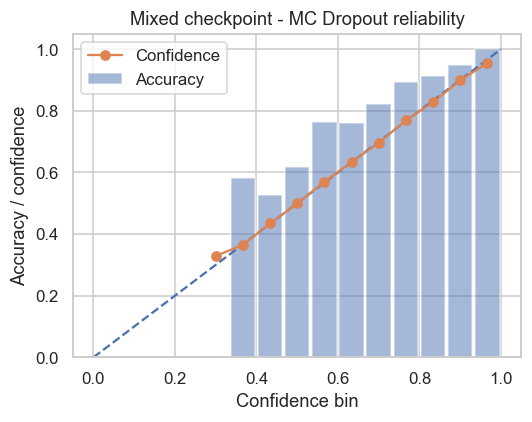

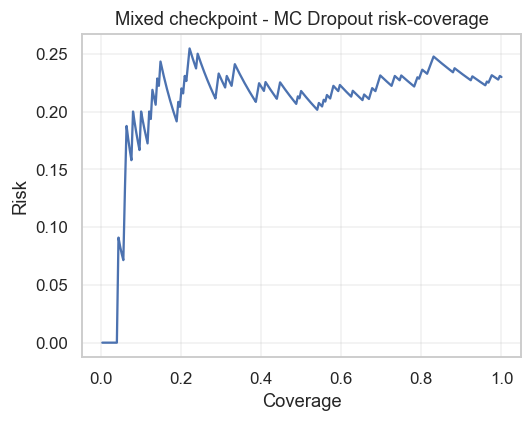

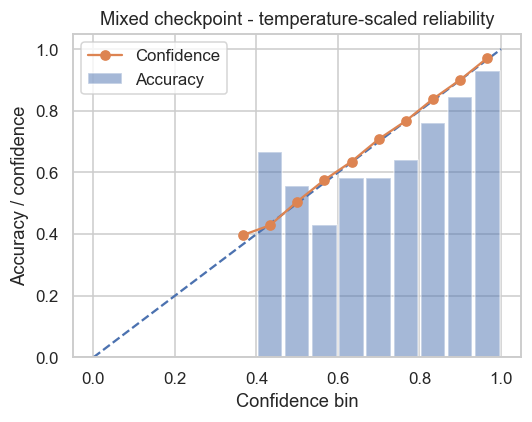

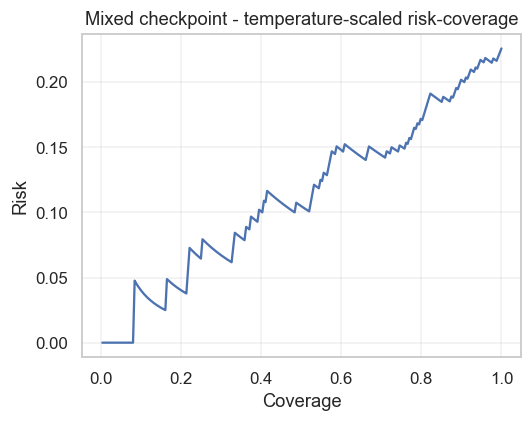

In [ ]:
EPS = 1e-12

def grade_logits(model: nn.Module, x: torch.Tensor) -> torch.Tensor:
    out = model(x)
    return out["grade"] if isinstance(out, dict) else out

def predictive_entropy(prob: np.ndarray, axis: int = -1) -> np.ndarray:
    p = np.clip(prob, EPS, 1.0)
    return -np.sum(p * np.log(p), axis=axis)

def mean_prob_and_entropy(samples: np.ndarray):
    if samples.ndim != 3:
        raise ValueError(f"expected (T, N, C); got {samples.shape}")
    mean_prob = samples.mean(axis=0)
    H_mean = predictive_entropy(mean_prob)
    E_H = predictive_entropy(samples, axis=-1).mean(axis=0)
    mi = np.clip(H_mean - E_H, 0.0, None)
    return mean_prob, H_mean, mi

def max_softmax_uncertainty(prob: np.ndarray) -> np.ndarray:
    return 1.0 - prob.max(axis=-1)

def expected_calibration_error(prob: np.ndarray, y_true: np.ndarray, *, n_bins: int = 15) -> Dict[str, Any]:
    confs = prob.max(axis=-1)
    preds = prob.argmax(axis=-1)
    correct = (preds == y_true).astype(np.float64)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_idx = np.clip(np.digitize(confs, edges[1:-1], right=True), 0, n_bins - 1)
    bin_count = np.zeros(n_bins, dtype=np.int64)
    bin_conf = np.zeros(n_bins, dtype=np.float64)
    bin_acc = np.zeros(n_bins, dtype=np.float64)
    for b in range(n_bins):
        m = bin_idx == b
        bin_count[b] = int(m.sum())
        if bin_count[b]:
            bin_conf[b] = float(confs[m].mean())
            bin_acc[b] = float(correct[m].mean())
    w = bin_count / max(len(y_true), 1)
    gaps = np.abs(bin_conf - bin_acc)
    ece = float((gaps * w).sum())
    mce = float(gaps[bin_count > 0].max()) if bin_count.sum() else 0.0
    return {
        "ece": ece,
        "mce": mce,
        "n_bins": n_bins,
        "bin_count": bin_count.tolist(),
        "bin_conf": bin_conf.tolist(),
        "bin_acc": bin_acc.tolist(),
        "bin_edges": edges.tolist(),
    }

def brier_score(prob: np.ndarray, y_true: np.ndarray, num_classes: int = NUM_CLASSES) -> float:
    oh = np.eye(num_classes)[y_true.astype(int)]
    return float(np.mean(np.sum((prob - oh) ** 2, axis=-1)))

def selective_prediction(prob: np.ndarray, y_true: np.ndarray, uncertainty: np.ndarray) -> Dict[str, Any]:
    y_pred = prob.argmax(axis=-1)
    err = (y_pred != y_true).astype(np.float64)
    order = np.argsort(uncertainty)
    risks = np.cumsum(err[order]) / np.arange(1, len(y_true) + 1)
    coverages = np.arange(1, len(y_true) + 1) / len(y_true)
    aurc = float(np.trapezoid(risks, coverages)) if hasattr(np, "trapezoid") else float(np.trapz(risks, coverages))

    def _at(c: float) -> float:
        k = max(1, int(round(c * len(y_true))))
        return float(risks[k - 1])

    return {"aurc": aurc, "coverages": coverages, "risks": risks, "risk@80": _at(0.8), "risk@90": _at(0.9), "risk@100": _at(1.0)}

def error_detection_auroc(uncertainty: np.ndarray, y_true: np.ndarray, prob: np.ndarray) -> float:
    y_pred = prob.argmax(axis=-1)
    is_err = (y_pred != y_true).astype(int)
    if is_err.sum() in (0, len(is_err)):
        return float("nan")
    return float(roc_auc_score(is_err, uncertainty))

def _set_mc_dropout(model: nn.Module) -> None:
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            m.train()

@torch.no_grad()
def predict_mc_dropout(model: nn.Module, loader: DataLoader, device: torch.device, *, T: int = MCD_T):
    y_ref = None
    passes: List[np.ndarray] = []
    for t in range(T):
        _set_mc_dropout(model)
        probs_t, ys_t = [], []
        for x, target in tqdm(loader, desc=f"MCD {t+1}/{T}", leave=False, dynamic_ncols=True):
            x = x.to(device, non_blocking=True)
            logits = grade_logits(model, x)
            probs_t.append(torch.softmax(logits, dim=-1).float().cpu().numpy())
            ys_t.append(target["grade"].numpy())
        probs_t = np.concatenate(probs_t).astype(np.float32)
        ys_t = np.concatenate(ys_t).astype(np.int64)
        if y_ref is None:
            y_ref = ys_t
        else:
            assert np.array_equal(y_ref, ys_t), "loader order changed across MCD passes"
        passes.append(probs_t)
    return y_ref, np.stack(passes, axis=0)

@torch.no_grad()
def collect_logits(model: nn.Module, loader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    ys, logits_out = [], []
    model.eval()
    for x, target in tqdm(loader, desc="collect_logits", leave=False, dynamic_ncols=True):
        x = x.to(device, non_blocking=True)
        logits = grade_logits(model, x).float().cpu().numpy()
        logits_out.append(logits)
        ys.append(target["grade"].numpy())
    return np.concatenate(ys).astype(np.int64), np.concatenate(logits_out).astype(np.float32)

def fit_temperature(val_logits: np.ndarray, val_labels: np.ndarray, device: torch.device, *, max_iter: int = 100) -> float:
    logits_t = torch.tensor(val_logits, dtype=torch.float32, device=device)
    labels_t = torch.tensor(val_labels, dtype=torch.long, device=device)
    log_T = torch.nn.Parameter(torch.zeros((), device=device))
    opt = LBFGS([log_T], lr=0.1, max_iter=max_iter)

    def closure():
        opt.zero_grad(set_to_none=True)
        T = torch.exp(log_T)
        loss = F.cross_entropy(logits_t / T, labels_t)
        loss.backward()
        return loss

    opt.step(closure)
    return float(torch.exp(log_T).detach().cpu())

def apply_temperature(logits: np.ndarray, T: float) -> np.ndarray:
    z = logits / float(T)
    z = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(z)
    return (exp_z / exp_z.sum(axis=1, keepdims=True)).astype(np.float32)

def evaluate_uncertainty_outputs(name: str, y_true: np.ndarray, y_prob: np.ndarray, uncertainty: np.ndarray) -> Dict[str, Any]:
    bundle = compute_metrics(y_true, y_prob.argmax(axis=1), y_prob)
    cal = expected_calibration_error(y_prob, y_true, n_bins=15)
    sel = selective_prediction(y_prob, y_true, uncertainty)
    return {
        "name": name,
        "accuracy": bundle.accuracy,
        "balanced_accuracy": bundle.balanced_accuracy,
        "macro_f1": bundle.macro_f1,
        "quadratic_kappa": bundle.quadratic_kappa,
        "macro_auroc": bundle.macro_auroc,
        "nll": float(-np.log(np.clip(y_prob[np.arange(len(y_true)), y_true], EPS, 1.0)).mean()),
        "brier": brier_score(y_prob, y_true),
        "ece": cal["ece"],
        "mce": cal["mce"],
        "aurc": sel["aurc"],
        "risk@80": sel["risk@80"],
        "risk@90": sel["risk@90"],
        "error_auroc": error_detection_auroc(uncertainty, y_true, y_prob),
        "reliability": cal,
        "coverage": sel["coverages"],
        "risk": sel["risks"],
    }

def save_uncertainty_npz(name: str, *, y_true, y_pred, y_prob, **extra) -> Path:
    path = UNCERTAINTY_DIR / f"{name}.npz"
    np.savez_compressed(path, y_true=y_true.astype(np.int64), y_pred=y_pred.astype(np.int64), y_prob=y_prob.astype(np.float32), **extra)
    return path

def plot_reliability_diagram(rel: Dict[str, Any], title: str, save_path: Path) -> None:
    conf = np.asarray(rel["bin_conf"], dtype=np.float32)
    acc = np.asarray(rel["bin_acc"], dtype=np.float32)
    cnt = np.asarray(rel["bin_count"], dtype=np.int64)
    edges = np.asarray(rel["bin_edges"], dtype=np.float32)
    centers = 0.5 * (edges[:-1] + edges[1:])
    plt.figure(figsize=(5, 4))
    plt.plot([0, 1], [0, 1], linestyle="--")
    mask = cnt > 0
    plt.bar(centers[mask], acc[mask], width=(edges[1] - edges[0]) * 0.9, alpha=0.5, label="Accuracy")
    plt.plot(centers[mask], conf[mask], marker="o", label="Confidence")
    plt.xlabel("Confidence bin")
    plt.ylabel("Accuracy / confidence")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def plot_risk_coverage(cov: np.ndarray, risk: np.ndarray, title: str, save_path: Path) -> None:
    plt.figure(figsize=(5, 4))
    plt.plot(cov, risk)
    plt.xlabel("Coverage")
    plt.ylabel("Risk")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

mixed_model = mixed_out["model"]
loaders = mixed_out["loaders"]

# MC Dropout on the mixed checkpoint
mcd_y, prob_T = predict_mc_dropout(mixed_model, loaders["test"], device, T=MCD_T)
mcd_prob, mcd_entropy, mcd_mi = mean_prob_and_entropy(prob_T)
mcd_unc = mcd_mi if np.isfinite(mcd_mi).all() else mcd_entropy
mcd_eval = evaluate_uncertainty_outputs("mixed_mcd", mcd_y, mcd_prob, mcd_unc)
save_uncertainty_npz("mixed_mcd", y_true=mcd_y, y_pred=mcd_prob.argmax(axis=1), y_prob=mcd_prob, prob_T=prob_T.astype(np.float32), entropy=mcd_entropy.astype(np.float32), mutual_info=mcd_mi.astype(np.float32))

# Temperature scaling on the same mixed checkpoint
val_y_temp, val_logits_temp = collect_logits(mixed_model, loaders["val"], device)
test_y_temp, test_logits_temp = collect_logits(mixed_model, loaders["test"], device)
T_star = fit_temperature(val_logits_temp, val_y_temp, device)
temp_prob = apply_temperature(test_logits_temp, T_star)
temp_unc = max_softmax_uncertainty(temp_prob)
temp_eval = evaluate_uncertainty_outputs("mixed_temp", test_y_temp, temp_prob, temp_unc)
save_uncertainty_npz("mixed_temp", y_true=test_y_temp, y_pred=temp_prob.argmax(axis=1), y_prob=temp_prob, logits=test_logits_temp.astype(np.float32), temperature=np.float32(T_star))

uncertainty_summary = pd.DataFrame([
    {k: v for k, v in mcd_eval.items() if k not in {"reliability", "coverage", "risk"}},
    {k: v for k, v in temp_eval.items() if k not in {"reliability", "coverage", "risk"}},
]).round(4)
uncertainty_summary.to_csv(UNCERTAINTY_DIR / "uncertainty_summary.csv", index=False)

display(uncertainty_summary)
print(f"Temperature scaling T*: {T_star:.4f}")

plot_reliability_diagram(mcd_eval["reliability"], "Mixed checkpoint - MC Dropout reliability", UNCERTAINTY_DIR / "mixed_mcd_reliability.png")
plot_risk_coverage(np.asarray(mcd_eval["coverage"]), np.asarray(mcd_eval["risk"]), "Mixed checkpoint - MC Dropout risk-coverage", UNCERTAINTY_DIR / "mixed_mcd_risk_coverage.png")
plot_reliability_diagram(temp_eval["reliability"], "Mixed checkpoint - temperature-scaled reliability", UNCERTAINTY_DIR / "mixed_temp_reliability.png")
plot_risk_coverage(np.asarray(temp_eval["coverage"]), np.asarray(temp_eval["risk"]), "Mixed checkpoint - temperature-scaled risk-coverage", UNCERTAINTY_DIR / "mixed_temp_risk_coverage.png")


## 8. Explainability evalaution on mixed solution

Grad-CAM target layer:
Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)
Selected 25 images total
Class distribution in selected subset:
myopic_maculopathy_grade
0    5
1    5
2    5
3    5
4    5
Name: count, dtype: int64


C:\Users\Isaac\AppData\Local\Temp\ipykernel_34012\3033613973.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(N_PER_CLASS, len(g)), random_state=RANDOM_SUBSET_SEED))


,image,myopic_maculopathy_grade,age,sex,height,weight,data_center
0,mmac_task_1_val_0071.png,1,38,female,NaN,NaN,1
1,mmac_task_1_val_0240.png,3,56,NaN,NaN,NaN,2
2,mmac_task_1_val_0172.png,0,63,male,NaN,NaN,1
3,mmac_task_1_val_0244.png,4,52,NaN,NaN,NaN,2
4,mmac_task_1_val_0234.png,2,66,NaN,NaN,NaN,2


Saving outputs to: a:\Applied AI\group work\AppliedAIGroupProject\outputs\mixed_mtl\explainability\gradcam_selected


Grad-CAM selected subset: 100%|██████████| 25/25 [00:06<00:00,  3.60it/s]

Saved Grad-CAM outputs:
a:\Applied AI\group work\AppliedAIGroupProject\outputs\mixed_mtl\explainability\gradcam_selected


,image_name,img_path,y_true,y_pred,confidence,correct,overlay_path,heatmap_path,heatmap_npy_path,original_path,prob_0,prob_1,prob_2,prob_3,prob_4
0,mmac_task_1_val_0071.png,a:\Applied AI\group work\AppliedAIGroupProject...,1,0,0.669305,0,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,0.669305,0.016514,0.085027,0.074936,0.154219
1,mmac_task_1_val_0240.png,a:\Applied AI\group work\AppliedAIGroupProject...,3,3,0.929930,1,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,0.015313,0.001312,0.006332,0.929930,0.047113
2,mmac_task_1_val_0172.png,a:\Applied AI\group work\AppliedAIGroupProject...,0,0,0.643043,1,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,0.643043,0.012446,0.077937,0.071095,0.195479
3,mmac_task_1_val_0244.png,a:\Applied AI\group work\AppliedAIGroupProject...,4,4,0.706486,1,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,0.000434,0.179513,0.003383,0.110184,0.706486
4,mmac_task_1_val_0234.png,a:\Applied AI\group work\AppliedAIGroupProject...,2,2,0.836183,1,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,a:\Applied AI\group work\AppliedAIGroupProject...,0.001278,0.025857,0.836183,0.086934,0.049748


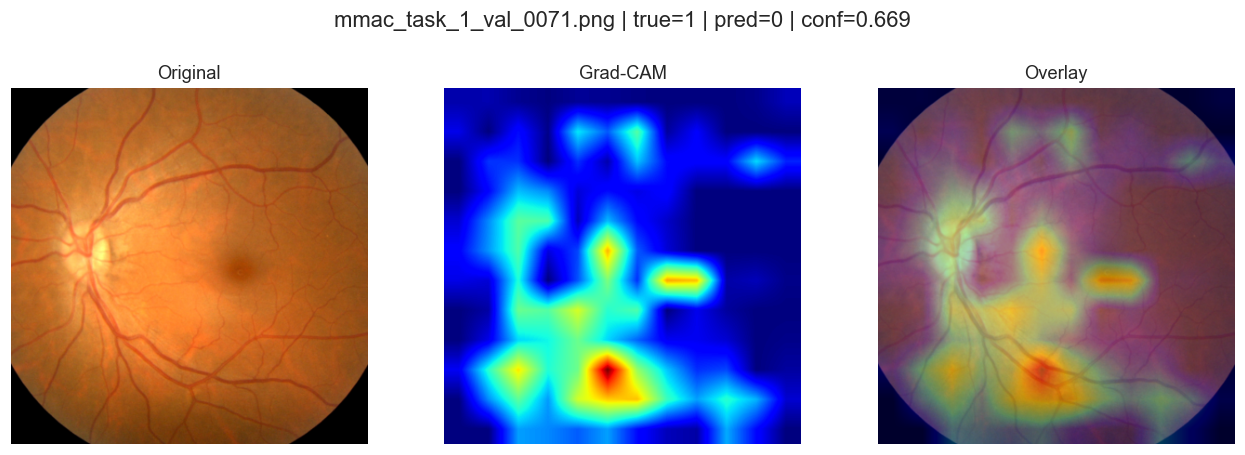

Quantitative eval images: 25
Fractions: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
Saving outputs to: a:\Applied AI\group work\AppliedAIGroupProject\outputs\mixed_mtl\explainability\faithfulness_eval


Deletion/Insertion AUC:   0%|          | 0/25 [00:00<?, ?it/s]C:\Users\Isaac\AppData\Local\Temp\ipykernel_34012\3033613973.py:204: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))
Deletion/Insertion AUC: 100%|██████████| 25/25 [00:05<00:00,  4.23it/s]


,image_name,img_path,y_true,y_pred,target_class,original_target_prob,deletion_auc,insertion_auc,faithfulness_gap
0,mmac_task_1_val_0071.png,a:\Applied AI\group work\AppliedAIGroupProject...,1,0,0,0.669305,0.341507,0.391856,0.050349
1,mmac_task_1_val_0240.png,a:\Applied AI\group work\AppliedAIGroupProject...,3,3,3,0.929930,0.477217,0.866898,0.389682
2,mmac_task_1_val_0172.png,a:\Applied AI\group work\AppliedAIGroupProject...,0,0,0,0.643043,0.315686,0.407336,0.091650
3,mmac_task_1_val_0244.png,a:\Applied AI\group work\AppliedAIGroupProject...,4,4,4,0.706486,0.203348,0.874582,0.671234
4,mmac_task_1_val_0234.png,a:\Applied AI\group work\AppliedAIGroupProject...,2,2,2,0.836183,0.124334,0.711550,0.587216


,metric,value
0,mean_deletion_auc,0.254033
1,std_deletion_auc,0.125448
2,mean_insertion_auc,0.613310
3,std_insertion_auc,0.225037
4,mean_faithfulness_gap,0.359276


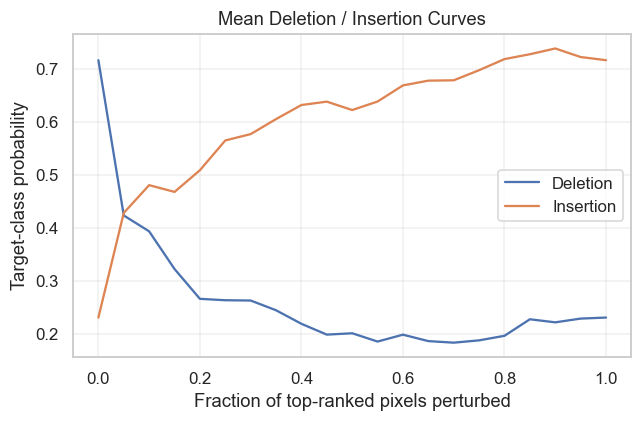

Saved explainability outputs to: a:\Applied AI\group work\AppliedAIGroupProject\outputs\mixed_mtl\explainability


In [9]:
def denormalize_tensor(img_tensor: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(3, 1, 1)
    return img_tensor * std + mean


def tensor_to_numpy_image(img_tensor: torch.Tensor) -> np.ndarray:
    x = denormalize_tensor(img_tensor.detach().cpu()).clamp(0, 1)
    return np.transpose(x.numpy(), (1, 2, 0)).astype(np.float32)


def make_overlay(image_np: np.ndarray, cam_np: np.ndarray, alpha: float = 0.35) -> np.ndarray:
    cmap = plt.get_cmap("jet")
    heat = cmap(np.clip(cam_np, 0, 1))[..., :3]
    return np.clip((1 - alpha) * image_np + alpha * heat, 0.0, 1.0)


def save_rgb_image(path: Path, image_np: np.ndarray) -> None:
    Image.fromarray((np.clip(image_np, 0.0, 1.0) * 255).astype(np.uint8)).save(path)


def load_eval_tensor(image_path: Path, image_size: int) -> Tuple[torch.Tensor, np.ndarray]:
    image = Image.open(image_path).convert("RGB")
    tfm = build_eval_transform(image_size)
    img_tensor = tfm(image)
    image_np = tensor_to_numpy_image(img_tensor)
    return img_tensor.unsqueeze(0), image_np


def plot_gradcam_triplet(image_np: np.ndarray, cam_np: np.ndarray, overlay_np: np.ndarray, title: str = "", figsize: Tuple[int, int] = (12, 4)) -> None:
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes[0].imshow(image_np)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(cam_np, cmap="jet")
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")
    axes[2].imshow(overlay_np)
    axes[2].set_title("Overlay")
    axes[2].axis("off")
    if title:
        fig.suptitle(title, y=1.03)
    plt.tight_layout()
    plt.show()


class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.handles = []
        self.handles.append(self.target_layer.register_forward_hook(self._forward_hook))
        self.handles.append(self.target_layer.register_full_backward_hook(self._backward_hook))

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        for h in self.handles:
            h.remove()
        self.handles = []

    def generate(self, x: torch.Tensor, class_idx: Optional[int] = None) -> Dict[str, Any]:
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        logits = grade_logits(self.model, x)
        probs = torch.softmax(logits, dim=1)
        pred_class = int(torch.argmax(probs, dim=1).item())
        target_class = pred_class if class_idx is None else int(class_idx)
        score = logits[:, target_class].sum()
        score.backward()
        activations = self.activations
        gradients = self.gradients
        if activations is None or gradients is None:
            raise RuntimeError("Grad-CAM hooks did not capture activations/gradients.")
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam[0, 0]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam_np = cam.detach().cpu().numpy().astype(np.float32)
        return {
            "logits": logits.detach().cpu().numpy()[0],
            "probs": probs.detach().cpu().numpy()[0],
            "pred_class": pred_class,
            "target_class": target_class,
            "cam": cam_np,
        }


model_for_xai = mixed_out["model"]
target_layer = model_for_xai.backbone.layer4[-1]
gradcam = GradCAM(model_for_xai, target_layer)
print("Grad-CAM target layer:")
print(target_layer)

true_label_lookup = dict(zip(mixed_out["loaders"]["test_ds"].frame[IMAGE_COL], mixed_out["loaders"]["test_ds"].frame[LABEL_COL]))
test_labels_df = mixed_out["loaders"]["test_ds"].frame.copy()
selected_df = (
    test_labels_df.groupby(LABEL_COL, group_keys=False)
    .apply(lambda g: g.sample(n=min(N_PER_CLASS, len(g)), random_state=RANDOM_SUBSET_SEED))
    .reset_index(drop=True)
)
selected_df = selected_df.sample(frac=1.0, random_state=RANDOM_SUBSET_SEED).reset_index(drop=True)
SELECTED_IMAGE_NAMES = selected_df[IMAGE_COL].tolist()

gradcam_dir = EXPLAINABILITY_DIR / "gradcam_selected"
heatmap_dir = gradcam_dir / "heatmaps"
overlay_dir = gradcam_dir / "overlays"
original_dir = gradcam_dir / "originals"
for d in [gradcam_dir, heatmap_dir, overlay_dir, original_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Selected {len(SELECTED_IMAGE_NAMES)} images total")
print("Class distribution in selected subset:")
print(selected_df[LABEL_COL].value_counts().sort_index())
display(selected_df.head())
print(f"Saving outputs to: {gradcam_dir}")


def run_gradcam_on_image(image_path: Path, model: nn.Module, gradcam: GradCAM, image_size: int, class_idx: Optional[int] = None) -> Dict[str, Any]:
    x, image_np = load_eval_tensor(image_path, image_size=image_size)
    x = x.to(device)
    result = gradcam.generate(x, class_idx=class_idx)
    cam_np = result["cam"]
    overlay_np = make_overlay(image_np, cam_np, alpha=0.35)
    image_name = image_path.name
    y_true = true_label_lookup.get(image_name, None)
    pred_class = result["pred_class"]
    probs = result["probs"]
    confidence = float(probs[pred_class])
    return {
        "image_name": image_name,
        "img_path": str(image_path),
        "y_true": None if y_true is None else int(y_true),
        "y_pred": int(pred_class),
        "confidence": confidence,
        "target_class": int(result["target_class"]),
        "probs": probs,
        "cam": cam_np,
        "image_np": image_np,
        "overlay_np": overlay_np,
    }


selected_rows = []
for image_name in tqdm(SELECTED_IMAGE_NAMES, desc="Grad-CAM selected subset"):
    image_path = TEST_DIR / image_name
    if not image_path.exists():
        print(f"[skip] Missing image: {image_path}")
        continue
    out = run_gradcam_on_image(image_path, model_for_xai, gradcam, mixed_cfg.image_size, class_idx=None)
    save_rgb_image(original_dir / image_name, out["image_np"])
    save_rgb_image(overlay_dir / image_name, out["overlay_np"])
    heatmap_uint8 = (np.clip(out["cam"], 0, 1) * 255).astype(np.uint8)
    Image.fromarray(heatmap_uint8).save(heatmap_dir / image_name)
    np.save(heatmap_dir / f"{Path(image_name).stem}.npy", out["cam"])
    row = {
        "image_name": out["image_name"],
        "img_path": out["img_path"],
        "y_true": out["y_true"],
        "y_pred": out["y_pred"],
        "confidence": out["confidence"],
        "correct": None if out["y_true"] is None else int(out["y_true"] == out["y_pred"]),
        "overlay_path": str(overlay_dir / image_name),
        "heatmap_path": str(heatmap_dir / image_name),
        "heatmap_npy_path": str(heatmap_dir / f"{Path(image_name).stem}.npy"),
        "original_path": str(original_dir / image_name),
    }
    for c in range(NUM_CLASSES):
        row[f"prob_{c}"] = float(out["probs"][c])
    selected_rows.append(row)

gradcam_df = pd.DataFrame(selected_rows)
gradcam_df.to_csv(gradcam_dir / "gradcam_selected_summary.csv", index=False)
print("Saved Grad-CAM outputs:")
print(gradcam_dir)
display(gradcam_df.head())

if len(gradcam_df):
    row = gradcam_df.iloc[0]
    image_np = np.array(Image.open(row["original_path"]).convert("RGB")).astype(np.float32) / 255.0
    overlay_np = np.array(Image.open(row["overlay_path"]).convert("RGB")).astype(np.float32) / 255.0
    cam_np = np.load(row["heatmap_npy_path"])
    title = f"{row['image_name']} | true={row['y_true']} | pred={row['y_pred']} | conf={row['confidence']:.3f}"
    plot_gradcam_triplet(image_np, cam_np, overlay_np, title=title)

fractions = np.linspace(0.0, 1.0, FAITHFULNESS_STEPS, dtype=np.float32)
quant_dir = EXPLAINABILITY_DIR / "faithfulness_eval"
quant_dir.mkdir(parents=True, exist_ok=True)
print(f"Quantitative eval images: {len(SELECTED_IMAGE_NAMES)}")
print(f"Fractions: {fractions}")
print(f"Saving outputs to: {quant_dir}")


def auc_trapz(y: np.ndarray, x: np.ndarray) -> float:
    return float(np.trapz(y, x))


def build_binary_masks_from_cam(cam_np: np.ndarray, fractions: np.ndarray, device: torch.device) -> torch.Tensor:
    h, w = cam_np.shape
    flat = cam_np.reshape(-1)
    order = np.argsort(-flat)
    n = flat.size
    masks = []
    for frac in fractions:
        k = int(round(float(frac) * n))
        mask_flat = np.zeros(n, dtype=np.float32)
        if k > 0:
            mask_flat[order[:k]] = 1.0
        masks.append(mask_flat.reshape(1, h, w))
    return torch.from_numpy(np.stack(masks, axis=0)).to(device)


@torch.no_grad()
def get_target_probs(model: nn.Module, batch_x: torch.Tensor, target_class: int) -> np.ndarray:
    logits = grade_logits(model, batch_x)
    probs = torch.softmax(logits, dim=1)
    return probs[:, target_class].detach().cpu().numpy().astype(np.float32)


def compute_deletion_insertion_for_image(image_path: Path, model: nn.Module, gradcam: GradCAM, image_size: int, device: torch.device, fractions: np.ndarray, class_idx: Optional[int] = None) -> Dict[str, Any]:
    x, image_np = load_eval_tensor(image_path, image_size=image_size)
    x = x.to(device)
    gc = gradcam.generate(x, class_idx=class_idx)
    cam_np = gc["cam"]
    pred_class = int(gc["pred_class"])
    target_class = int(gc["target_class"])
    probs = gc["probs"]
    original_target_prob = float(probs[target_class])
    masks = build_binary_masks_from_cam(cam_np, fractions, device=device)
    s = masks.shape[0]
    x_rep = x.repeat(s, 1, 1, 1)
    baseline = torch.zeros_like(x_rep)
    deletion_batch = x_rep * (1.0 - masks) + baseline * masks
    insertion_batch = baseline * (1.0 - masks) + x_rep * masks
    deletion_probs = get_target_probs(model, deletion_batch, target_class)
    insertion_probs = get_target_probs(model, insertion_batch, target_class)
    return {
        "image_name": image_path.name,
        "img_path": str(image_path),
        "y_true": true_label_lookup.get(image_path.name, None),
        "pred_class": pred_class,
        "target_class": target_class,
        "original_target_prob": original_target_prob,
        "deletion_auc": auc_trapz(deletion_probs, fractions),
        "insertion_auc": auc_trapz(insertion_probs, fractions),
        "cam": cam_np,
        "fractions": fractions.copy(),
        "deletion_probs": deletion_probs.copy(),
        "insertion_probs": insertion_probs.copy(),
    }


faithfulness_rows = []
faithfulness_curve_rows = []
for image_name in tqdm(SELECTED_IMAGE_NAMES, desc="Deletion/Insertion AUC"):
    image_path = TEST_DIR / image_name
    if not image_path.exists():
        print(f"[skip] Missing image: {image_path}")
        continue
    out = compute_deletion_insertion_for_image(image_path, model_for_xai, gradcam, mixed_cfg.image_size, device, fractions, class_idx=None)
    faithfulness_rows.append({
        "image_name": out["image_name"],
        "img_path": out["img_path"],
        "y_true": None if out["y_true"] is None else int(out["y_true"]),
        "y_pred": int(out["pred_class"]),
        "target_class": int(out["target_class"]),
        "original_target_prob": float(out["original_target_prob"]),
        "deletion_auc": float(out["deletion_auc"]),
        "insertion_auc": float(out["insertion_auc"]),
        "faithfulness_gap": float(out["insertion_auc"] - out["deletion_auc"]),
    })
    for frac, dprob, iprob in zip(out["fractions"], out["deletion_probs"], out["insertion_probs"]):
        faithfulness_curve_rows.append({
            "image_name": out["image_name"],
            "fraction": float(frac),
            "deletion_prob": float(dprob),
            "insertion_prob": float(iprob),
            "y_true": None if out["y_true"] is None else int(out["y_true"]),
            "y_pred": int(out["pred_class"]),
            "target_class": int(out["target_class"]),
        })

faithfulness_df = pd.DataFrame(faithfulness_rows)
faithfulness_curves_df = pd.DataFrame(faithfulness_curve_rows)
faithfulness_df.to_csv(quant_dir / "faithfulness_summary.csv", index=False)
faithfulness_curves_df.to_csv(quant_dir / "faithfulness_curves.csv", index=False)
display(faithfulness_df.head())

faithfulness_summary = pd.DataFrame({
    "metric": ["mean_deletion_auc", "std_deletion_auc", "mean_insertion_auc", "std_insertion_auc", "mean_faithfulness_gap"],
    "value": [
        faithfulness_df["deletion_auc"].mean() if len(faithfulness_df) else np.nan,
        faithfulness_df["deletion_auc"].std(ddof=1) if len(faithfulness_df) > 1 else np.nan,
        faithfulness_df["insertion_auc"].mean() if len(faithfulness_df) else np.nan,
        faithfulness_df["insertion_auc"].std(ddof=1) if len(faithfulness_df) > 1 else np.nan,
        faithfulness_df["faithfulness_gap"].mean() if len(faithfulness_df) else np.nan,
    ],
})
display(faithfulness_summary)

curve_mean_df = faithfulness_curves_df.groupby("fraction", as_index=False)[["deletion_prob", "insertion_prob"]].mean() if len(faithfulness_curves_df) else pd.DataFrame(columns=["fraction", "deletion_prob", "insertion_prob"])
if len(curve_mean_df):
    plt.figure(figsize=(6, 4))
    plt.plot(curve_mean_df["fraction"], curve_mean_df["deletion_prob"], label="Deletion")
    plt.plot(curve_mean_df["fraction"], curve_mean_df["insertion_prob"], label="Insertion")
    plt.xlabel("Fraction of top-ranked pixels perturbed")
    plt.ylabel("Target-class probability")
    plt.title("Mean Deletion / Insertion Curves")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(quant_dir / "faithfulness_mean_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

print(f"Saved explainability outputs to: {EXPLAINABILITY_DIR}")
